In [25]:
import h5py
import numpy as np
import pandas as pd
# import xgboost classifier
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
# import metrics for multiclass classification
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import root_mean_squared_error, r2_score
from scipy.stats import spearmanr
# stratify train-test split
from sklearn.model_selection import KFold, train_test_split
# import cross-validation
from sklearn.model_selection import cross_val_score

# import RandomSearchCV for hyperparameter tuning
from sklearn.model_selection import RandomizedSearchCV


In [2]:
pax_db = pd.read_parquet(
    "/nfs/cds-peta/exports/biol_micro_cds_gr_sunagawa/scratch/vbezshapkin/protein-abundance-PMDA2025/data/raw/all_organisms_filtered_without_M.musculus_KIDNEY.parquet"
).query("is_integrated")

In [3]:
additional_data = pd.read_csv(
    "/nfs/cds-peta/exports/biol_micro_cds_gr_sunagawa/scratch/vbezshapkin/protein-abundance-PMDA2025/data/raw/train_added_M.musculus_KIDNEY_data.csv.gz"
)

In [4]:
pax_db = pd.concat([pax_db, additional_data], ignore_index=True)

In [29]:
emb_dict = {}
with h5py.File("/nfs/cds-peta/exports/biol_micro_cds_gr_sunagawa/scratch/vbezshapkin/protein-abundance-PMDA2025/data/processed/emb_mouse.npz") as f:
    for key, value in f.items():
        emb_dict[key] = value[:]

In [30]:
list(emb_dict.keys())[0]

'A0A087WPY5'

In [31]:
embs = pd.DataFrame.from_dict(
    emb_dict, orient="index", columns=[f"emb_{i}" for i in range(emb_dict['A0A087WPY5'].shape[0])]
).reset_index().rename(columns={"index": "UniprotAccession"}).set_index("UniprotAccession")

In [32]:
abundance = pax_db.query("sample_organ == 'KIDNEY' & organism_name == 'M.musculus'")
abundance["abundance"] = abundance.abundance.apply(lambda x: np.log10(x + 1e-6))

/tmp/ipykernel_2400423/2902501755.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  abundance["abundance"] = abundance.abundance.apply(lambda x: np.log10(x + 1e-6))


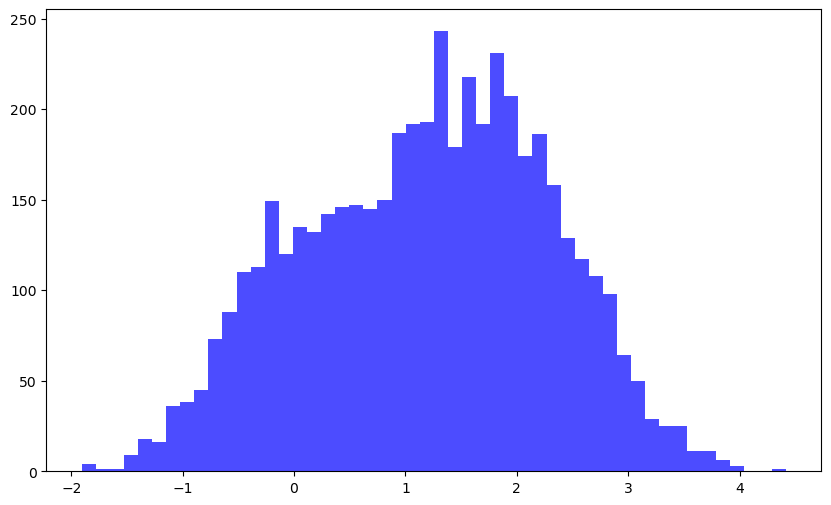

In [33]:
# plot abundances
import matplotlib.pyplot as plt
abundance = abundance[["UniprotAccession", "abundance"]].groupby("UniprotAccession")[["abundance"]].mean().reset_index()
plt.figure(figsize=(10, 6))
plt.hist(abundance.abundance, bins=50, color='blue', alpha=0.7);

In [34]:
# split dataset into 3 percentiles
abundance["abundance_group"] = pd.qcut(abundance.abundance, q=3, labels=["low", "medium", "high"])

In [35]:
# print bin ranges for abundance
print(abundance.groupby("abundance_group").abundance.agg(["min", "max"]))

                      min       max
abundance_group                    
low             -1.907617  0.710222
medium           0.710530  1.768889
high             1.769159  4.418157


/tmp/ipykernel_2400423/3049744469.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(abundance.groupby("abundance_group").abundance.agg(["min", "max"]))


In [36]:
df = abundance[["UniprotAccession", "abundance_group"]].dropna()

In [37]:
df = df.join(embs, on="UniprotAccession", how="inner").reset_index(drop=True).drop(columns="UniprotAccession")

In [38]:
X, y = df.drop(columns=["abundance_group"]), df["abundance_group"]
# stratified split by abundance group
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42, stratify=y
)

# encode labels
le = LabelEncoder()

y_train = le.fit_transform(y_train)
y_test = le.transform(y_test)

In [39]:
from eBoruta import eBoruta
# fit XGBoost classifier
model = XGBClassifier(
    n_estimators=1000,
    max_depth=6,
    learning_rate=0.1,
    objective='multi:softmax',
    num_class=3,
    random_state=42,
    n_jobs=32
)

# feature selection
feat_selector = eBoruta(
    n_iter=10,
    classification=True,
    pvalue=0.05,
    test_size=0.1,
    test_stratify=True,
    verbose=2
)

feat_selector.fit(X_train.values, y_train)

/nfs/cds-peta/exports/biol_micro_cds_gr_sunagawa/scratch/vbezshapkin/conda-envs/pmda-valentyn/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/nfs/cds-peta/exports/biol_micro_cds_gr_sunagawa/scratch/vbezshapkin/conda-envs/pmda-valentyn/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/nfs/cds-peta/exports/biol_micro_cds_gr_sunagawa/scratch/vbezshapkin/conda-envs/pmda-valentyn/lib/python3.12/site-packages/sklearn/utils/deprecation.py:132: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
 99%|===================| 1304/1311 [00:48<00:00]        /nfs/cds-peta/exports/biol_micro_cds_gr_sunagawa/scratch/vb

,n_iter,10
,classification,True
,percentile,100
,pvalue,0.05
,test_size,0.1
,test_stratify,True
,shap,True
,shap_gpu_tree,False
,shap_approximate,False
,shap_check_additivity,False
,importance_getter,None


In [57]:
# no feature selection
model.fit(X_train, y_train)
# predict
preds = model.predict(X_test)

# plot results and metrices for multiclass classification
print(classification_report(y_test, preds, target_names=le.classes_))
print("Accuracy:", accuracy_score(y_test, preds))

              precision    recall  f1-score   support

        high       0.64      0.65      0.65       162
         low       0.61      0.64      0.62       162
      medium       0.46      0.43      0.44       161

    accuracy                           0.57       485
   macro avg       0.57      0.57      0.57       485
weighted avg       0.57      0.57      0.57       485

Accuracy: 0.5731958762886598


In [55]:
X_feature_selected = X_train.loc[:, ~feat_selector.features_.rejected_mask]
# fit model on selected features
model.fit(X_feature_selected, y_train)


# predict
preds = model.predict(X_test.loc[:, ~feat_selector.features_.rejected_mask])

# plot results and metrices for multiclass classification
print(classification_report(y_test, preds, target_names=le.classes_))
print("Accuracy:", accuracy_score(y_test, preds))

              precision    recall  f1-score   support

        high       0.63      0.65      0.64       162
         low       0.58      0.61      0.59       162
      medium       0.44      0.40      0.42       161

    accuracy                           0.55       485
   macro avg       0.55      0.55      0.55       485
weighted avg       0.55      0.55      0.55       485

Accuracy: 0.554639175257732


<Axes: >

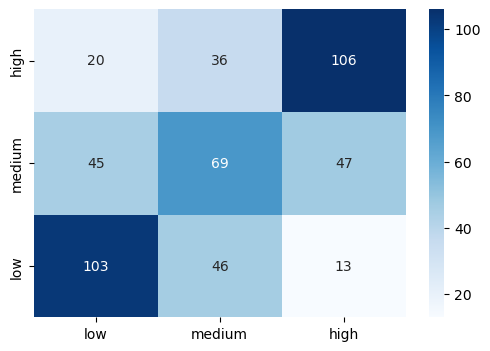

In [61]:
import seaborn as sns

# plot confusion matrix
cm = confusion_matrix(y_test, preds)
plt.figure(figsize=(6, 4))
order = ["high", "medium", "low" ]  # order of labels in the confusion matrix

# recreate order of labels
cm = cm[np.argsort([le.transform([label])[0] for label in order])][:, np.argsort([le.transform([label])[0] for label in order])]
# reverse x axis
cm = cm[:, ::-1]

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=order[::-1], yticklabels=order)

In [114]:
# test dataset
test_df = pd.read_csv("/nfs/cds-peta/exports/biol_micro_cds_gr_sunagawa/scratch/vbezshapkin/protein-abundance-PMDA2025/data/raw/test2_masked_dropped_M.musculus_KIDNEY_data.csv")
test_df.shape

(540, 14)

In [115]:
true_test = test_df[["UniprotAccession"]].join(embs, on="UniprotAccession", how="inner").reset_index(drop=True).set_index("UniprotAccession")

In [116]:
# predict on true test
test_preds = model.predict(true_test)

In [119]:
# make a dataframe with UniprotAccession and predicted abundance group
test_results = pd.DataFrame({
    "UniprotAccession": true_test.index,
    "predicted_abundance_group": le.inverse_transform(test_preds)
})

In [122]:
test_results.to_csv("../results/abundance_group_prediction.csv")